# Exercise on the use of OLS, Lasso, Ridge and PCR regression

In this exercise we'll check the difference between some regression algorithms.

The goal is to predict a measure of the progression of diabetes from some input features, such as age, body weight, etc.

## The diabetes dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

data = load_diabetes(scaled = False)
features = data.feature_names
X, y = data.data, data.target

print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [7]:
# Quick look at the data
df = pd.DataFrame(X, columns=features)
df['target'] = y
df.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,48.52,1.47,26.38,94.65,189.14,115.44,49.79,4.07,4.64,91.26,152.13
std,13.11,0.50,4.42,13.83,34.61,30.41,12.93,1.29,0.52,11.50,77.09
min,19.00,1.00,18.00,62.00,97.00,41.60,22.00,2.00,3.26,58.00,25.00
25%,38.25,1.00,23.20,84.00,164.25,96.05,40.25,3.00,4.28,83.25,87.00
50%,50.00,1.00,25.70,93.00,186.00,113.00,48.00,4.00,4.62,91.00,140.50
75%,59.00,2.00,29.28,105.00,209.75,134.50,57.75,5.00,5.00,98.00,211.50
max,79.00,2.00,42.20,133.00,301.00,242.40,99.00,9.09,6.11,124.00,346.00


We can produce 2D plots to show the marginal relationship between each feature and the target. Be careful though: these simple plots do not account for the effect of other variables and can therfore be misleading if read alone.

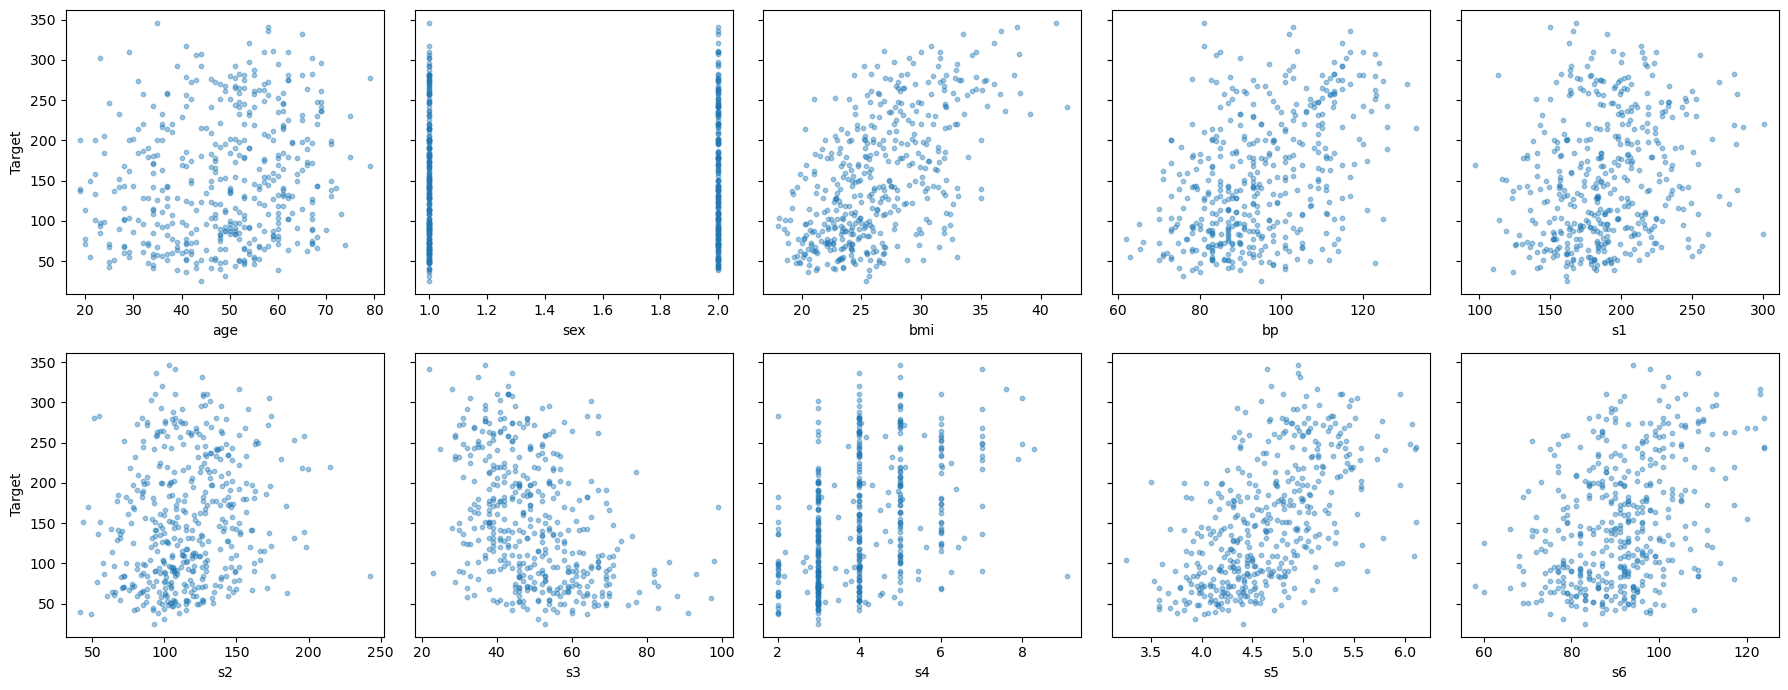

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)

for i, ax in enumerate(axes.flatten()):
    ax.scatter(X[:, i], y, alpha=0.4, s=10)
    ax.set_xlabel(features[i])

axes[0, 0].set_ylabel('Target')
axes[1, 0].set_ylabel('Target')
plt.tight_layout()
plt.show()

## Splitting and scaling the dataset

In [ ]:
# To do:
# - Split the data into train and test
# - Center and scale the data
# - Look at the data in X0_train now (using pd.DataFrame): does it look as expected?


# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# Ordinary Least-Squares regression

A general regression problem can be written as: $y = f(\mathbf{x})$  with $y \in \mathbb{R}$, $x \in \mathbb{R}^d$ and $f: \mathbb{R}^d \mapsto \mathbb{R}$.
In linear regression, the function is represented by an array of weights: $y = \mathbf{w}^T \mathbf{x} = \sum_{i}^d w_i x_i$.

We need to tune the weights to our process, so we collect some data on the inputs $\mathbf{x}$ and the target $y$. The objective is to tune the weights to minimize the euclidean distance between the observations $\mathbf{y} \in \mathbb{R}^n$ and the predictions $\mathbf{X} \mathbf{w}$:

$\mathbf{w} = \underset{\mathbf{w}}{\mathrm{min}} ||\mathbf{X}\mathbf{w} - \mathbf{y}||^2_2$

In [ ]:
# To do: 
# - Fit a Ordinary least squares regression model
# - Do a parity plot (observed vs predicted)

# from sklearn.linear_model import LinearRegression


# Uncomment these lines for a parity plot. y_test is the ground truth, y_OLS is the ordinary least square prediction

# plt.scatter(y_test, y_pred_OLS)
# plt.plot(y_test, y_test, c='r', alpha=0.6, ls='--')
# plt.xlim(y_test.min()-5, y_test.max()+5)
# plt.ylim(y_test.min()-5, y_test.max()+5)
# plt.xlabel('Observed target')
# plt.ylabel('Predicted target')
# plt.show()

## Performance metrics

To assess the quality of the regression model, we need to compare the predictions and observations for some points that were not used to train the model.
There are a huge number of different metrics that can be used depending on the case.
Some popular ones are the coefficient of determination $R^2$ and the (root) mean squared error (R)MSE:
\begin{equation}
R^2(\mathbf{y}, \hat{\mathbf{y}}) = 1-\frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
\end{equation}

\begin{equation}
\mathrm{MSE}(\mathbf{y}, \hat{\mathbf{y}}) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
\end{equation}

\begin{equation}
\mathrm{RMSE}(\mathbf{y}, \hat{\mathbf{y}}) = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}
\end{equation}

An overview of error metrics can be found here: https://scikit-learn.org/stable/modules/model_evaluation.html#which-scoring-function-should-i-use.

Note that the lower the MSE and RMSE values, the better the model is, while the higher the R2 score (up to 1), the better the model

In [ ]:
# To do:
# - Compute the r2, mse and rmse

# from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

# Lasso regression

In the OLS regression model, we have been relying on all the input features. However, some features might be correlated with each other or not even be correlated with the output, hence decreasing the accuracy of the model. The LASSO regression model penalizes the coefficients that are different from zero, forcing the weights to be active only if they improve the model.

The objective function of the LASSO regression problem is:

$\mathbf{w} = \underset{\mathbf{w}}{\mathrm{min}} \frac{1}{2 n} ||\mathbf{X}\mathbf{w} - \mathbf{y}||^2_2 + \alpha ||\mathbf{w}||_1$

In which the coefficient $\alpha$ controls how much we regularize the model.

In [ ]:
# To do:
# - Compute the Lasso regression with a random alpha
# - Print the coefficients of the OLS and Lasso models. What do you observe?
# - Print the r2 score of the the models

# from sklearn.linear_model import Lasso

The penalty on the L1 norm is used to promote the sparsity of the regression weights.

To infer the correct value of $\alpha$ to apply we can use the cross-validation.

### What is cross-validation?

A key and general risk in Machine Learning is overfitting, in which the model learns the training data "too well" (including noise and random fluctuations) rather than the underlying, generalizable patterns. A clear sign of overfitting is a model performing very well on train data, but poorly on the test data. Cross-Validation is a solution to mitigate the risk of overfitting, by traning the model several times on different data splits and averaging its performance.

 In the case of $k$-fold Cross-Validation:

1. Split the data into $k$ equal parts (folds).
2. Train the model $k$ times, each time leaving one fold out as a validation set and using the rest of the data as training data.
3. Average the performance across the $k$ runs.

![Img](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)



### Using Cross-Validation for our Lasso regression

In our case, we use CV on the training set only, such that we find the optimal $\alpha$ without touching our actual test set. 
In `LassoCV` and `RidgeCV` (which we will see later), scikit-learn uses this procedure to automatically select the best regularization parameter $\alpha$.

In [47]:
# To do:
# - use LassoCV to find the optimal alpha
# - Print the LassoCV coefficients and compare with the Lasso model. What do you observe?

# from sklearn.linear_model import LassoCV


In [48]:
# Visual comparison of coefficients --> uncomment these lines by selecting them and using the shortcut "ctrl + /" (if you used other names, replace the names of OLS_reg, Lasso_reg etc... accordingly)


# fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# axes[0].barh(features, OLS_reg.coef_)
# axes[0].set_title('OLS coefficients')
# axes[0].axvline(0, color='k', lw=0.5)

# axes[1].barh(features, Lasso_reg.coef_)
# axes[1].set_title('Lasso (α=1) coefficients')
# axes[1].axvline(0, color='k', lw=0.5)

# axes[2].barh(features, LassoCV_reg.coef_)
# axes[2].set_title(f'LassoCV (α={LassoCV_reg.alpha_:.2f}) coefficients')
# axes[2].axvline(0, color='k', lw=0.5)

# plt.tight_layout()
# plt.show()

IMPORTANT: Each coefficient represents a conditional association: it tells us the relationship between that feature and the target while holding all other features constant. This can differ from what you see in the marginal plots from the beginning of the session. Also, regression coefficients do not imply causality. Drawing causal conclusions requires additional assumptions (e.g., experimental design or causal inference methods) that go beyond fitting a regression model.

### Example in which Lasso regression in useful:

Let's add 150 features of pure noise and compare how a simple Ordinary Least-Square Regression and a Lasso regression would handle it.

In [49]:
# Add 150 columns of pure noise

np.random.seed(42)
n_noise = 150
X_noise = np.random.randn(X.shape[0], n_noise)
X_aug = np.hstack([X, X_noise])
features_aug = features + [f'noise_{i}' for i in range(n_noise)]

print(f'Original number of features: {X.shape[1]}')
print(f'After adding noise: {X_aug.shape[1]}')

Original number of features: 10
After adding noise: 160


In [50]:
# TO DO: as done in the previous exercise,
# 1. Perform a train/test split on this new dataset
# 2. Create a scaler (and fit it on the correct dataset! Be careful about leaking between training and test data)
# 3. Perform OLS and Lasso
# 4. Compare the r2 score when using the obtained models on the test dataset. Print and compare the coefficients of each (using .coef_).
# 5. What do you observe? Is it as expected?

## Ridge regression

In other cases, you could have corelated variables, which are all equally important. You would still want to use this data for the regression, while still wanting robustness against noise. Ridge regression allows to do this, as the regularization is applied to the $l_2$ norm of the weights. This allows to reduce the total magnitude of the weights, so that the model is less sensitive to noise, while still keeping all features for the regression.
The objective function of a Ridge regression problem is:

$\mathbf{w} = \underset{\mathbf{w}}{\mathrm{min}} ||\mathbf{X}\mathbf{w} - \mathbf{y}||^2_2 + \alpha ||\mathbf{w}||_2$

In [ ]:
# To do:
# - Use RidgeCV to fit the ridge model
# - Print the Ridge coefficients. Compare with the other models. What do you observe?

# from sklearn.linear_model import RidgeCV

Let's illustrate a case in which the Ridge regression can be useful. The following dataset is created artificially: instead of adding pure noise (like we did to illustrate the use of Lasso), we add new features, which are correlated to the initial ones. This is purely for didactical purposes: we assume that these features represent something and are just as important as the other features

In [ ]:
X_aug = None
features_aug = None
np.random.seed(42)
n_decoys = 250
noise_level = 0.1

decoy_features = []
for i in range(n_decoys):
    # Pick 3 random real columns
    cols = np.random.choice(X.shape[1], size=3, replace=False)
    
    # Random convex weights: x, y, 1-x-y (with x+y <= 1)
    x = np.random.uniform(0, 1)
    y_w = np.random.uniform(0, 1 - x)
    z_w = 1 - x - y_w
    
    decoy = (x * X[:, cols[0]] 
             + y_w * X[:, cols[1]] 
             + z_w * X[:, cols[2]] 
             + noise_level * np.random.randn(X.shape[0]))
    
    decoy_features.append(decoy)

X_aug = np.hstack([X, np.column_stack(decoy_features)])
features_aug = features + [f'decoy_{i}' for i in range(n_decoys)]

print(f'Original features: {X.shape[1]}')
print(f'After adding decoys: {X_aug.shape[1]}')

In [ ]:
# TO DO: as done in the previous exercises,
# 1. Perform a train/test split on this new dataset
# 2. Create a scaler (and fit it on the correct dataset! Be careful about leaking between training and test data)
# 3. Perform OLS and Ridge regressions
# 4. Compare the r2 score when using the obtained models on the test dataset. Print and compare the coefficients of each (using .coef_).
# 5. What do you observe? Is it as expected?
# 6. Try with Lasso. What do you observe in terms of performances? What can you conclude

## Principal components regression

The principal component regression is the same as the OLS regression, with an extra-step: the PCA is applied to the X matrix, and the linear regression is performed on the new projected data.

In [ ]:
# To do:
# - Compute the PCA transform of the training data (X0_train)
# - Fit a regression model on the transformed data (Z)
# - Compare the R2 score with OLS

# from sklearn.decomposition import PCA


This added step has two benefits:

* The features become uncorrelated between them.
* The dimensionality of the feature matrix can be reduced.

In [ ]:
# To do:
# - Do the same as in the previous cell using only 5 PCs

## Summary: when to use which method?

| Method | Use when... | Trade-off |
|--------|------------|----------|
| **OLS** | You have few features and trust they are all relevant. | No regularization — sensitive to noise and multicollinearity. |
| **Lasso** | You suspect many features are irrelevant and want automatic feature selection. | L1 penalty drives some coefficients exactly to zero. |
| **Ridge** | You expect many features to have small but nonzero contributions and want to reduce sensitivity to noise. | L2 penalty shrinks all coefficients but never zeroes them out. |
| **PCR** | Features are highly correlated and you want to work in a decorrelated, lower-dimensional space. | PCs that explain the most variance in X may not be the most predictive of y — consider PLS as an alternative. |